**Setting up environment**

In [ ]:
# Install required packages
!pip install nltk pandas numpy scikit-learn seaborn

# Import necessary libraries
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

**Loading and Understanding dataset**

In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()

# Read the dataset
df = pd.read_csv('train.csv')

# Explore the dataset
print(df.head())

print(df['score'].value_counts())

Saving train.csv to train (1).csv
  essay_id                                          full_text  score
0  000d118  Many people have car where they live. The thin...      3
1  000fe60  I am a scientist at NASA that is discussing th...      3
2  001ab80  People always wish they had the same technolog...      4
3  001bdc0  We all heard about Venus, the planet without a...      4
4  002ba53  Dear, State Senator\n\nThis is a letter to arg...      3
score
3    6280
2    4723
4    3926
1    1252
5     970
6     156
Name: count, dtype: int64


**Data Preprocessing**

In [ ]:
# Initialize NLTK tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Tokenization
    tokens = word_tokenize(text.lower())

    # Remove stopwords and non-alphabetic tokens
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token.isalpha() and token not in stop_words]

    return ' '.join(tokens)

# Apply preprocessing to essays
df['processed_text'] = df['full_text'].apply(preprocess_text)

# Encode the scores (if they're categorical)
le = LabelEncoder()
df['score_encoded'] = le.fit_transform(df['score'])

**Feature Extraction**

In [ ]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform the text data
X = tfidf.fit_transform(df['processed_text'])
y = df['score_encoded']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Model Building**

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial'),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': MultinomialNB()
}


results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)

    results.append({'Model': name, 'F1 Score': f1, 'Cohen\'s Kappa': kappa})

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


**Visualizing Results**

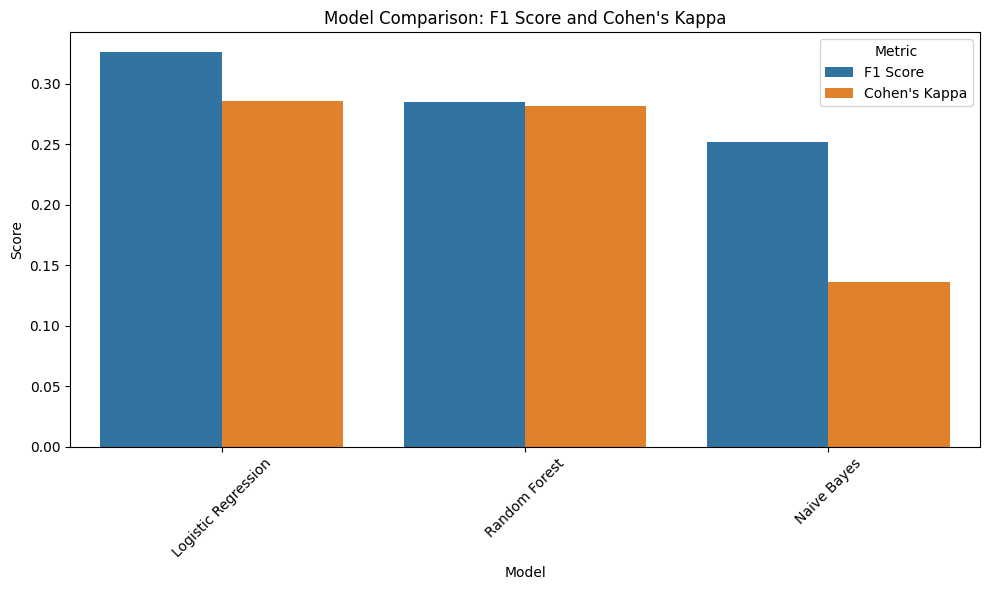

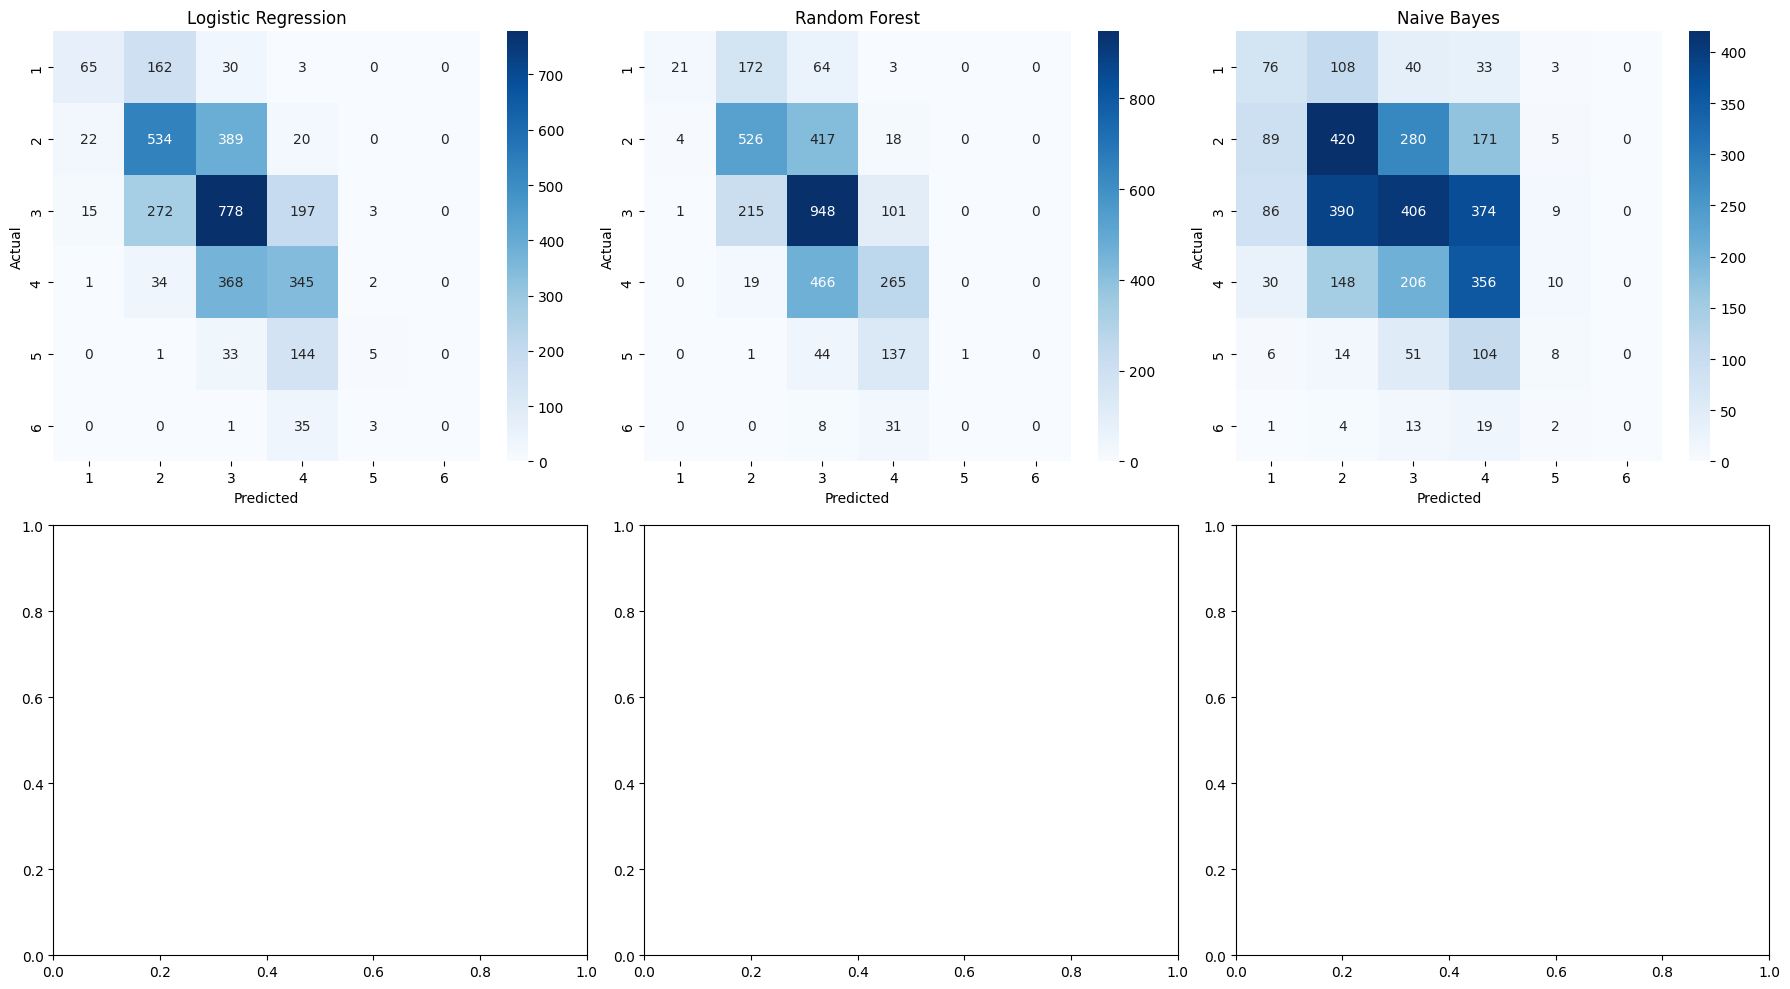

              Model  F1 Score  Cohen's Kappa
Logistic Regression     0.326          0.286
      Random Forest     0.285          0.282
        Naive Bayes     0.252          0.137


,Model,F1 Score,Cohen's Kappa
0,Logistic Regression,0.326,0.286
1,Random Forest,0.285,0.282
2,Naive Bayes,0.252,0.137


In [ ]:

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.melt(id_vars='Model', var_name='Metric', value_name='Score'),
            x='Model', y='Score', hue='Metric')
plt.xticks(rotation=45)
plt.title('Model Comparison: F1 Score and Cohen\'s Kappa')
plt.tight_layout()
plt.show()


from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[idx], xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


# Round values for better display
display_df = results_df.copy()
display_df['F1 Score'] = display_df['F1 Score'].round(3)
display_df["Cohen's Kappa"] = display_df["Cohen's Kappa"].round(3)

print(display_df.to_string(index=False))




# Round the scores for cleaner formatting
styled_df = results_df.copy()
styled_df['F1 Score'] = styled_df['F1 Score'].round(3)
styled_df["Cohen's Kappa"] = styled_df["Cohen's Kappa"].round(3)

# Style the table
styled_table = (
    styled_df.style
    .set_caption("Model Performance Comparison")
    .format({"F1 Score": "{:.3f}", "Cohen's Kappa": "{:.3f}"})
    .background_gradient(subset=["F1 Score"], cmap="Blues")
    .background_gradient(subset=["Cohen's Kappa"], cmap="Reds")
    .highlight_max(axis=0, color="None")
    .set_properties(**{'text-align': 'center'})
    .set_table_styles(
        [{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}]
    )
)

styled_table



